In [77]:
import os
import json
import time
import requests
import subprocess
from typing import Dict, List, Any, Optional, Tuple, TypedDict

from langchain.chat_models import ChatOpenAI
from langchain.tools import Tool
from langchain.schema import SystemMessage, HumanMessage, AIMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

from langgraph.checkpoint.memory import MemorySaver


In [78]:
# Location Coordinat lookup
from geopy.geocoders import Nominatim

In [79]:
from models.report_service_manager import ServiceManager
from models.llm_service_manager import BrainManager

In [80]:
class AgentState(TypedDict):
    messages: List[Dict[str,Any]]
    weather_data: Optional[Dict[str, Any]]
    news_data: Optional[Dict[str, Any]]
    jobs_data: Optional[Dict[str, Any]]
    command: Optional[str]
    tool_input: Optional[Dict[str, Any]]

# Initialing Phi-4 in Ollama
report_manager = ServiceManager()
brain_manager = BrainManager()

# Make sure services are running
brain_manager.ensure_services_running()



Ollama service is already running
API wrapper is already running


True

In [81]:
# brain_manager.stop_services()

In [82]:
# report_manager.stop_all_services()

In [83]:
def coord_lookup(location) -> dict:
    geolocator = Nominatim(user_agent="my_geocoder")
    coord = geolocator.geocode(location)
    if coord:  # Check if a valid result is returned
        return {location: f"{coord.latitude},{coord.longitude}"}
    else:
        return {location: "Location not found"}
print(coord_lookup("Seattle"))

{'Seattle': '47.6038321,-122.330062'}


In [84]:
# Function that interact with report APIs (weather, news, job)
def get_weather(location: str = None, days:int = 7) -> Dict[str, Any]:
    """Get weather forcast for a location."""
    weather_url = report_manager.ensure_service_running("weather")
    if not weather_url:
        return {"error":"Weather service unavaible."}
    
    if not location:
        location = "Seattle"
    default_coord = "47.69,-122.1808" # Seattle coorda
    
    # Converting location to lat/long
    locations_coord = coord_lookup(location)
    coordinates = locations_coord.get(location, default_coord)
    
    try:
        response = requests.get(f"{weather_url}/weather/{coordinates/{days}}")
        if response.status_code == 200:
            return response.json()
        else:
            return {"error": f"Weather API error: {response.status_code}"}
    except requests.RequestException as e:
        return {"error": f"Request failed: {str(e)}"}

def get_news(query: str, category: str = None, country: str = None) -> Dict[str, Any]:
    """Get new article based on query and optional category"""
    news_url = report_manager.ensure_service_running("news")
    
    if not news_url:
        return {"error": "News service unavailable."}
    
    params = {}
    if query:
        params["keywords"] = query
    if category:
        params["category"] = category    
    if country:
        params["country"] = country
    
    try:
        response = requests.get(f"{news_url}/news", params=params)
        if response.status_code == 200:
            return response.json()
        else:
            return {"error": f"News API error:{response.status_code}"}
    except requests.RequestException as e:
        return {"error": f"Request failed: {str(e)}"}
    
def search_job(job_title: str,
        location: Optional[str] = None,
        years_of_experience: Optional[str] = None,
        field: Optional[str] = None,
        date_posted: Optional[str] = None
        ) -> Dict[str, Any]:
    job_url = report_manager.ensure_service_running("jobs")
    if not job_url:
        return {"error":"Job services unavailable."}
    
    params = {"job_title": job_title}
    if location:
        params['location'] = location
    if field:
        params['field'] = field
    if years_of_experience:
        params['years_of_experience'] = years_of_experience
    if date_posted:
        params['date_posted'] = date_posted
    try:
        response = requests.get(f"{job_url}/jobs", params=params)
        if response.status_code==200:
            return response.json()
        else:
            return {"error": f"Job API Error: {response.status_code}"}
    except requests.RequestException as e:
        return {"error": f"Request failed: {str(e)}"}


In [85]:
# Conversation with LLM
def send_to_llm(messages: List[Dict[str,str]]) -> str:
    """Send messages to the Ollama API wrapper and get a message."""
    api_url = "http://localhost:8000/chat"
    
    formatted_messages = []
    for msg in messages:
        formatted_messages.append(
            {
                "role":msg["role"],
                "content": msg["content"]
            }
        )
    try:
        params = {
            "messages": json.dumps(formatted_messages),
            "temperature": 0.7,
            "num_predict": 1000 # i.e max token
        }
        
        response = requests.get(api_url,params = params)
        if response.status_code == 200:
            result = response.json()
            return result.get("response", "")
        else:
            return f"Error communicating with LLM: {response.status_code}"
    except requests.RequestException as e:
        return f"Request to LLM failed: {str(e)}"
    
    
        

In [86]:
# Create tools
weather_tool = Tool.from_function(
    func=get_weather,
    name = "get_weather",
    description= "Get weather forecast from a location"
)

news_tool = Tool.from_function(
    func= get_news,
    name = "get_news",
    description= "Get news article based on a query."
)

jobs_tool = Tool.from_function(
    func = search_job,
    name = "search_job",
    description= "Search for jobs based on title and location."
)

In [87]:
def agent(state: AgentState) -> Dict:
    """Main agent node that processes user input and routes to the appropriate node."""
    messages = state["messages"]
    
    # Extracting the latest users message:
    latest_user_msg = None
    for msg in reversed(messages):
        latest_user_msg = msg["content"]
        break
    if not latest_user_msg:
        state["messages"].append({"role": "assistant", "content": "I am not sure what you are asking for."})
        return {"next": END}
    # Format messages for LLM
    # Format messages for LLM
    llm_messages = [
        {
            "role": "system", 
            "content": """You are a helpful assistant with access to weather, news, and job search tools.
            Analyze the user's request and determine which tool to use.
            If they want weather information, respond with 'COMMAND: WEATHER' followed by the location.
            If they want news, respond with 'COMMAND: NEWS' followed by the search query.
            If they want job listings, respond with 'COMMAND: JOBS' followed by the job title and location.
            If they want a daily report, respond with 'COMMAND: DAILY_REPORT' followed by location for weather, search query for news, and job title for jobs.
            If no tool is needed, just respond normally."""
        }
    ]
    # Add conversation history
    for msg in messages:
        llm_messages.append(msg)
    
    # Get response from LLM
    llm_response = send_to_llm(llm_messages)
    
    # Check if response contains a command
    if "COMMAND: DAILY REPORT" in llm_response.upper():
        # Extract parameters for all three services
        parts = llm_response.upper().split("COMMAND: DAILY REPORT", 1)[1].strip().split(",")
        
        # Default values if parameters aren't provided
        weather_location = "Seattle"
        news_query = "Technology, Politics"
        job_title = "Data Scientist, Data Analyst"
        job_location = None
        
        # Parse parameters (with simple error handling)
        if len(parts) >= 1 and parts[0].strip():
            weather_location = parts[0].strip()
        if len(parts) >= 2 and parts[1].strip():
            news_query = parts[1].strip()
        if len(parts) >= 3:
            job_info = parts[2].strip()
            if " IN " in job_info:
                job_title, job_location = job_info.split(" IN ", 1)
            else:
                job_title = job_info    
                
        # Set state for daily report
        state["command"] = "daily_report"
        state["tool_input"] = {
            "weather_location": weather_location,
            "news_query": news_query,
            "job_title": job_title,
            "job_location": job_location
        }
        return {"next": "daily_report_node"}

    # Handle individual commands as before
    elif "COMMAND: WEATHER" in llm_response.upper():
        parts = llm_response.upper().split("COMMAND: WEATHER", 1)
        location = parts[1].strip() if len(parts) > 1 else "Seattle"
        state["command"] = "weather"
        state["tool_input"] = {"location": location}
        return {"next": "weather_node"}
    
    elif "COMMAND: NEWS" in llm_response.upper():
        parts = llm_response.upper().split("COMMAND: NEWS", 1)
        query = parts[1].strip() if len(parts) > 1 else "technology"
        state["command"] = "news"
        state["tool_input"] = {"query": query}
        return {"next": "news_node"}
        
    elif "COMMAND: JOBS" in llm_response.upper():
        parts = llm_response.upper().split("COMMAND: JOBS", 1)
        job_info = parts[1].strip() if len(parts) > 1 else "Data Scientist"
        job_title = job_info.split(" in ")[0] if " in " in job_info else job_info
        location = job_info.split(" in ")[1] if " in " in job_info else None
        state["command"] = "jobs"
        state["tool_input"] = {"job_title": job_title, "location": location}
        return {"next": "jobs_node"}
    
    # No command detected, just return the LLM response
    state["messages"].append({"role": "assistant", "content": llm_response})
    return {"next": END}

In [98]:
def daily_report_node(state: AgentState) -> Dict:
    """Process requests for a combined daily report with weather, news, and jobs"""
    tool_input = state["tool_input"]
    weather_location = tool_input.get("weather_location", "Seattle")
    news_query = tool_input.get("news_query", "technology")
    job_title = tool_input.get("job_title", "Data Scientist")
    job_location = tool_input.get("job_location")
    
    # Call all three APIs in sequence
    weather_data = get_weather(weather_location)
    news_data = get_news(news_query)
    jobs_data = search_job(job_title, job_location)
    
    # Store data in state
    state["weather_data"] = weather_data
    state["news_data"] = news_data
    state["jobs_data"] = jobs_data
    
    # Format combined response
    response = "📋 Your Daily Report\n\n"
    
    # Add weather section
    response += "🌤️ WEATHER FORECAST\n"
    if "error" in weather_data:
        response += f"Sorry, I couldn't get the weather information: {weather_data['error']}\n\n"
    else:
        location = weather_data.get("location", weather_location)
        forecast = weather_data.get("forecast", [])
        if forecast:
            response += f"Weather for {location}:\n"
            for day in forecast[:2]:  # Show first 2 days
                date = day.get("name", "")
                temp = day.get("temperature", "")
                condition = day.get("shortForecast", "")
                response += f"• {date}: {temp}°F, {condition}\n"
        else:
            response += f"Weather data for {location} is available, but no forecast details were found.\n"
    response += "\n"
    
    # Add news section
    response += "📰 NEWS UPDATES\n"
    if "error" in news_data:
        response += f"Sorry, I couldn't find news: {news_data['error']}\n\n"
    else:
        articles = news_data.get("result", [])
        if articles:
            response += f"Top news about '{news_query}':\n"
            for i, article in enumerate(articles[:2], 1):
                title = article.get("title", "Untitled")
                source = article.get("source", "Unknown source")
                response += f"{i}. {title} ({source})\n"
        else:
            response += f"I didn't find any news articles about '{news_query}'.\n"
    response += "\n"
    
    # Add jobs section
    response += "💼 JOB OPPORTUNITIES\n"
    if "error" in jobs_data:
        response += f"Sorry, I couldn't find jobs: {jobs_data['error']}\n"
    else:
        jobs = jobs_data.get("result", [])
        if jobs:
            location_str = f" in {job_location}" if job_location else ""
            response += f"Recent {job_title} jobs{location_str}:\n"
            for i, job in enumerate(jobs[:2], 1):
                title = job.get("title", "Untitled")
                company = job.get("company", "Unknown company")
                job_location = job.get("location", "")
                response += f"{i}. {title} at {company} ({job_location})\n"
        else:
            response += f"I didn't find any {job_title} jobs{' in ' + job_location if job_location else ''}.\n"
    
    state["messages"].append({"role": "assistant", "content": response})
    return {"next": END}

def weather_node(state: AgentState) -> Dict:
    """Process weather requests"""
    tool_input = state["tool_input"]
    location = tool_input.get("location", "Seattle")
    
    # Call weather API
    weather_data = get_weather(location)
    state["weather_data"] = weather_data
    
    # Format response
    if "error" in weather_data:
        response = f"Sorry, I couldn't get the weather information: {weather_data['error']}"
    else:
        location = weather_data.get("location", "the requested location")
        forecast = weather_data.get("forecast", [])
        if forecast:
            response = f"Weather forecast for {location}:\n\n"
            for day in forecast[:3]:  # Show first 3 days
                date = day.get("name", "")
                temp = day.get("temperature", "")
                condition = day.get("shortForecast", "")
                response += f"• {date}: {temp}°F, {condition}\n"
        else:
            response = f"Weather data for {location} is available, but no forecast details were found."
    
    state["messages"].append({"role": "assistant", "content": response})
    return {"next": END}

def news_node(state: AgentState) -> Dict:
    """Process news requests"""
    tool_input = state["tool_input"]
    query = tool_input.get("query", "technology")
    
    # Call news API
    news_data = get_news(query)
    state["news_data"] = news_data
    
    # Format response
    if "error" in news_data:
        response = f"Sorry, I couldn't find news: {news_data['error']}"
    else:
        articles = news_data.get("result", [])
        if articles:
            response = f"Here are some recent news about '{query}':\n\n"
            for i, article in enumerate(articles[:3], 1):
                title = article.get("title", "Untitled")
                source = article.get("source", "Unknown source")
                response += f"{i}. {title} ({source})\n"
            response += f"\nFound {len(articles)} articles in total."
        else:
            response = f"I didn't find any news articles about '{query}'."
    
    state["messages"].append({"role": "assistant", "content": response})
    return {"next": END}

def jobs_node(state: AgentState) -> Dict:
    """Process job search requests"""
    tool_input = state["tool_input"]
    job_title = tool_input.get("job_title", "Data Scientist")
    location = tool_input.get("location")
    
    # Call jobs API
    jobs_data = search_job(job_title, location)
    state["jobs_data"] = jobs_data
    
    # Format response
    if "error" in jobs_data:
        response = f"Sorry, I couldn't find jobs: {jobs_data['error']}"
    else:
        jobs = jobs_data.get("result", [])
        if jobs:
            location_str = f" in {location}" if location else ""
            response = f"Here are some recent {job_title} jobs{location_str}:\n\n"
            for i, job in enumerate(jobs[:3], 1):
                title = job.get("title", "Untitled")
                company = job.get("company", "Unknown company")
                job_location = job.get("location", "")
                response += f"{i}. {title} at {company} ({job_location})\n"
            response += f"\nFound {len(jobs)} jobs in total."
        else:
            response = f"I didn't find any {job_title} jobs{' in ' + location if location else ''}."
    
    state["messages"].append({"role": "assistant", "content": response})
    return {"next": END}

In [99]:
# Create LangGraph
workflow = StateGraph(AgentState)

# Add Node
workflow.add_node("agent", agent)
workflow.add_node("weather_node", weather_node)
workflow.add_node("news_node", news_node)
workflow.add_node("job_node", jobs_node)
workflow.add_node("daily_report_node", daily_report_node)

# Add Edge
workflow.add_edge(START, "agent")
workflow.add_edge("agent", END)
workflow.add_edge("agent", "weather_node")
workflow.add_edge("agent", "news_node")
workflow.add_edge("agent", "job_node")
workflow.add_edge("agent", "daily_report_node")
workflow.add_edge("weather_node", END)
workflow.add_edge("news_node", END)
workflow.add_edge("job_node", END)
workflow.add_edge("daily_report_node", END)

memory = MemorySaver()
app = workflow.compile(checkpointer = memory)


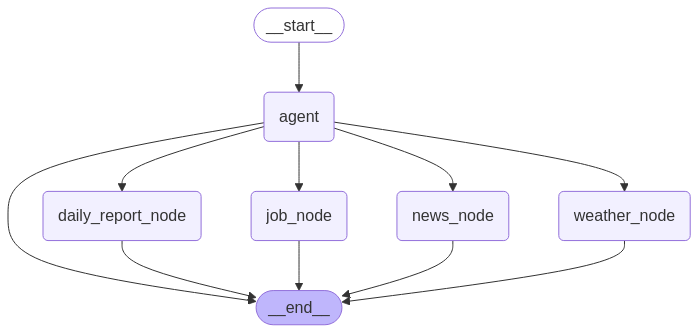

In [100]:
# Visualizing the graph using get_graph and one the "draw" method like "draw_ascii" or "draw_png"
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [101]:
config = {"configurable": {"thread_id": 1}}

In [106]:
# Helper function to chat with the agent
def chat(user_input: str, state: Optional[Dict] = None) -> Dict:
    """Process a user message and return the updated state"""
    if state is None:
        state = {
            "messages": [],
            "weather_data": None,
            "news_data": None, 
            "jobs_data": None,
            "command": None,
            "tool_input": {}  # Initialize with empty dict instead of None
        }
    
    # Add user message to state
    state["messages"].append({"role": "user", "content": user_input})
    
    # Process through graph
    result = app.invoke(state, config=config)
    
    return result

In [ ]:
# Example implementation
if __name__ == "__main__":
    try:
        print("Starting services...")
        
        # # Make sure all services are running
        # brain_manager.ensure_services_running()
        # print("LLM services are running")
        
        # Start conversation
        state = {"messages": []}
        
        print("\nAI Assistant: Hello! I can help you with weather forecasts, news updates, and job searches. What would you like to know?")
        
        while True:
            user_input = input("\nYou: ")
            if user_input.lower() in ["exit", "quit", "bye"]:
                break
                
            state = chat(user_input, state)
            
            # Print assistant's response
            for message in state["messages"]:
                if message["role"] == "assistant" and message.get("content"):
                    print(f"\nAI Assistant: {message['content']}")
    
    finally:
        # Clean up by stopping all services
        print("\nStopping services...")
        report_manager.stop_all_services()
        brain_manager.stop_services()
        print("All services stopped")

Starting services...

AI Assistant: Hello! I can help you with weather forecasts, news updates, and job searches. What would you like to know?



Stopping services...
stop_services method called
API process status: False
No API process to stop (it was None)
Ollama process status: False
No Ollama process to stop (it was None)
All services stopped


KeyError: 'tool_input'

: 